In [1]:
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt

import seaborn as sns

import scipy.stats as stats

from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.metrics import r2_score

In [2]:
path = "pre_processed.pkl"

df = pd.read_pickle(path)

In [3]:
df.shape

(8465, 16)

In [4]:
df.columns

Index(['Date', 'Rented Bike Count', 'Hour', 'Temperature(°C)', 'Humidity(%)',
       'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)',
       'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Seasons',
       'Day', 'Month', 'Year', 'Weekend_or_Holiday'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8465 entries, 0 to 8759
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Date                       8465 non-null   datetime64[ns]
 1   Rented Bike Count          8465 non-null   int64         
 2   Hour                       8465 non-null   category      
 3   Temperature(°C)            8465 non-null   float64       
 4   Humidity(%)                8465 non-null   int64         
 5   Wind speed (m/s)           8465 non-null   float64       
 6   Visibility (10m)           8465 non-null   int64         
 7   Dew point temperature(°C)  8465 non-null   float64       
 8   Solar Radiation (MJ/m2)    8465 non-null   float64       
 9   Rainfall(mm)               8465 non-null   float64       
 10  Snowfall (cm)              8465 non-null   float64       
 11  Seasons                    8465 non-null   category      
 12  Day        

In [17]:
df.sample(1).T

,8146
Date,2018-11-05 00:00:00
Rented Bike Count,28.106939
Hour,10
Temperature(°C),11.8
Humidity(%),59
Wind speed (m/s),0.9
Visibility (10m),616
Solar Radiation (MJ/m2),1.23
Rainfall(mm),0.0
Snowfall (cm),0.0


In [6]:
numerical_features = [col for col in df.columns if df[col].dtype in ['int64', 'float64']]

numerical_features

['Rented Bike Count',
 'Temperature(°C)',
 'Humidity(%)',
 'Wind speed (m/s)',
 'Visibility (10m)',
 'Dew point temperature(°C)',
 'Solar Radiation (MJ/m2)',
 'Rainfall(mm)',
 'Snowfall (cm)']

<Axes: >

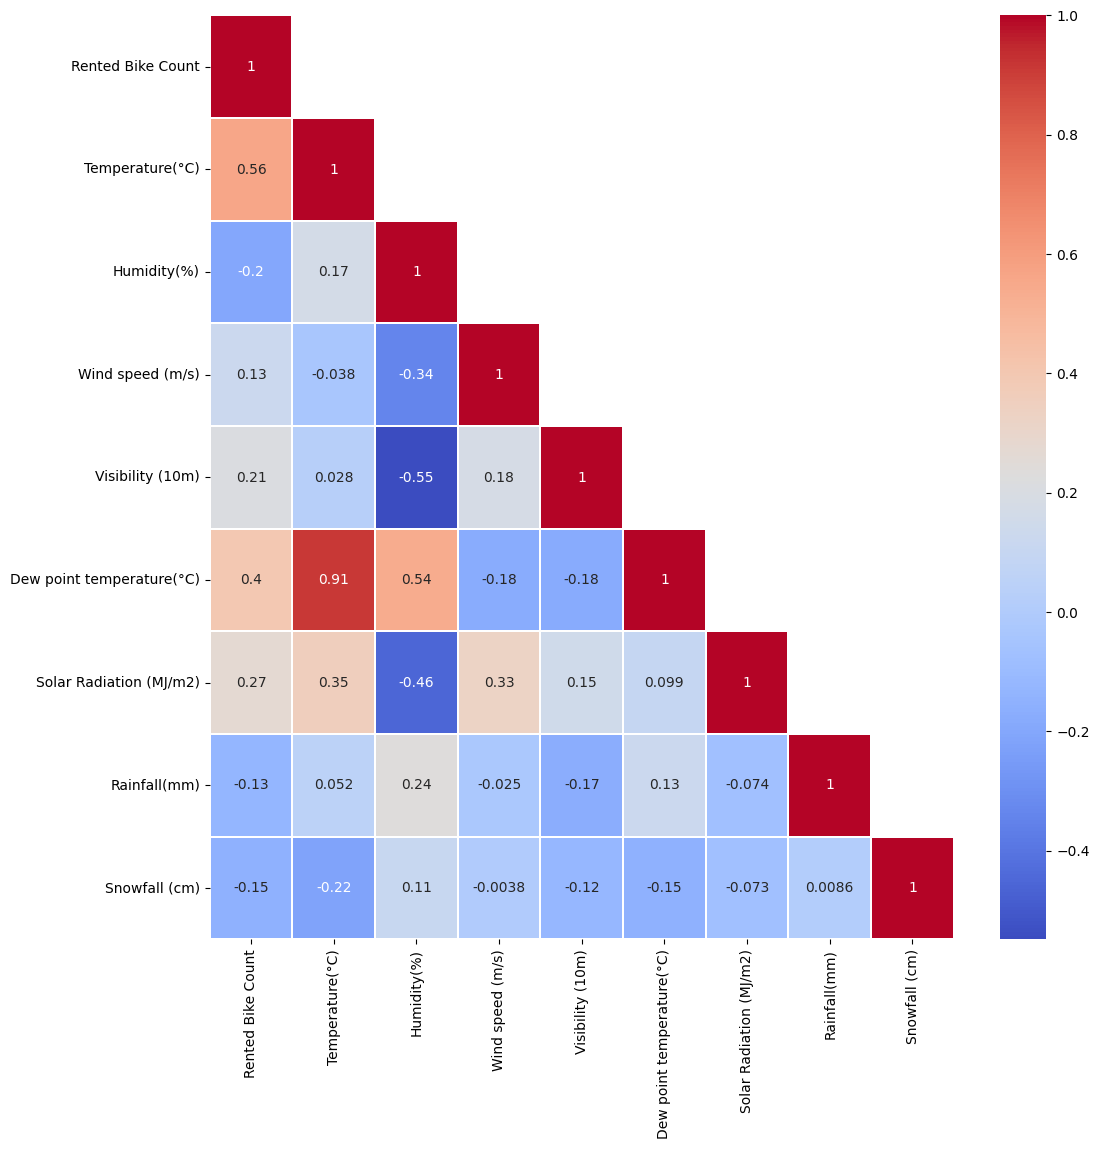

In [7]:
data_corr = df[numerical_features].corr()

plt.figure(figsize=(12,12))

mask = np.triu(np.ones_like(data_corr, dtype=bool), k=1)

sns.heatmap(data_corr, cmap='coolwarm', linewidths=0.1, annot=True, linecolor='white', mask=mask)

`temperature` and `Dew point temperature` have correlation of 0.91. So it's a multicollinearity issue. Hence we drop `Dew point temperature`.

In [8]:
df.drop(['Dew point temperature(°C)'], axis = 1, inplace=True)

Text(0.5, 1.0, 'Square root')

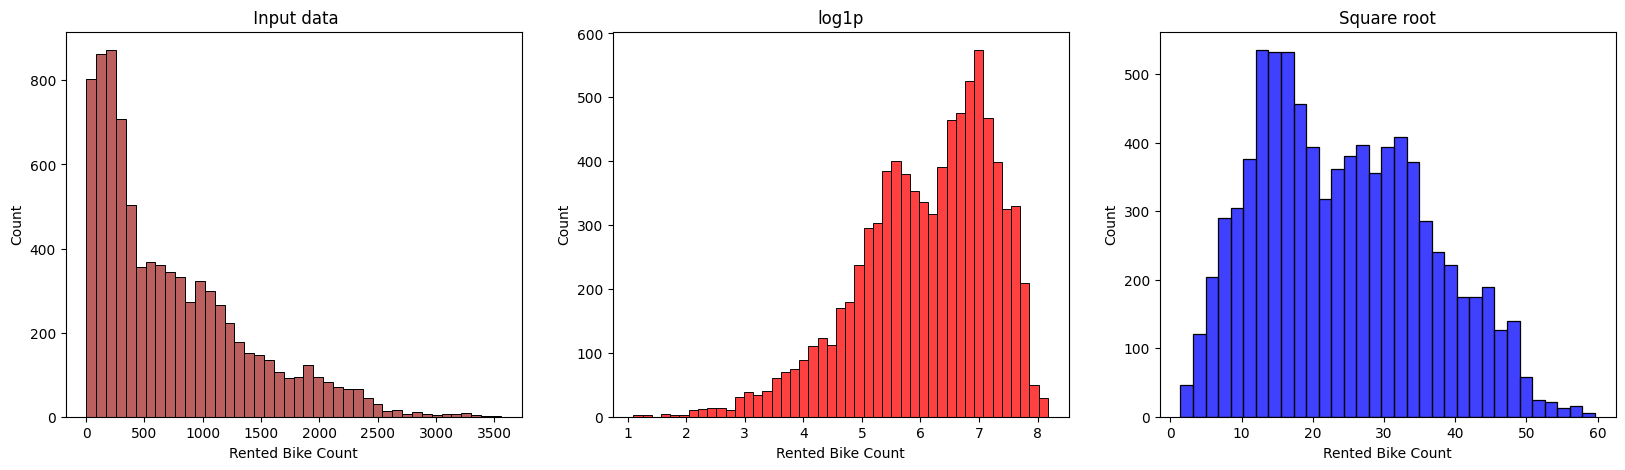

In [9]:
#apply diffrent tranformation technique and checking data distributation
fig,axes = plt.subplots(1,3,figsize=(20,5))
sns.histplot((df['Rented Bike Count']),ax=axes[0],color='brown').set_title(" Input data")
sns.histplot(np.log1p(df['Rented Bike Count']+0.0000001),ax=axes[1],color='red').set_title("log1p") #transform only posible in positive value and >0 value so add 0.0000001 in data
sns.histplot(np.sqrt(df['Rented Bike Count']),ax=axes[2], color='blue').set_title("Square root")

In [10]:
def plotvariable(df,variable):
  plt.figure(figsize=(10,5))
  plt.subplot(1,2,1)   # 1 row, 2 Columns and 1st plot
  df[variable].hist(bins=30)

  ## QQ plot
  plt.subplot(1,2,2)
  stats.probplot(df[variable], dist='norm',plot=plt)
  plt.show()

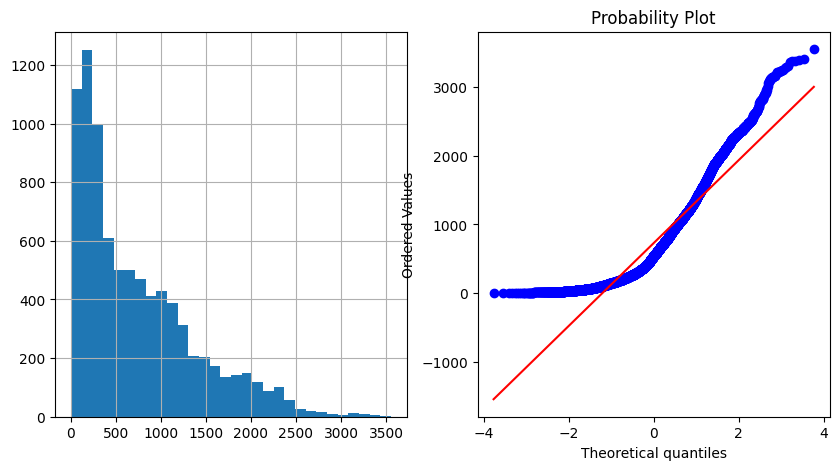

In [11]:
plotvariable(df,'Rented Bike Count')

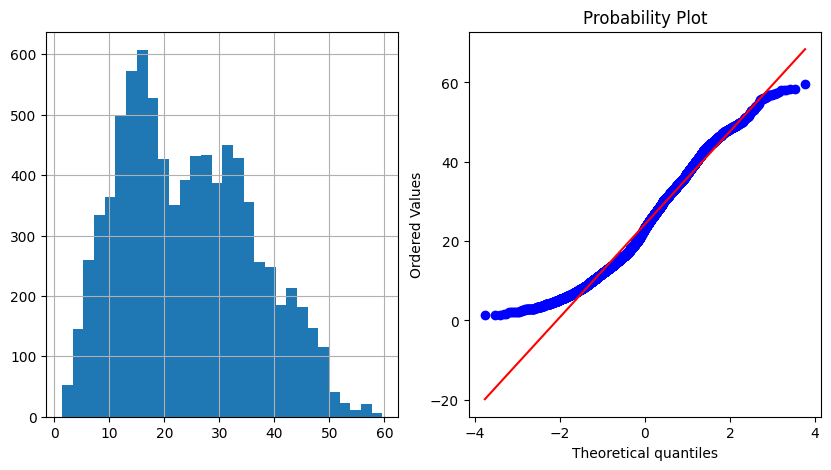

In [12]:
df['Rented Bike Count']=np.sqrt(df['Rented Bike Count'])

plotvariable(df,'Rented Bike Count')

In [13]:
le_df = df.apply(LabelEncoder().fit_transform)

In [16]:
le_df.columns

Index(['Date', 'Rented Bike Count', 'Hour', 'Temperature(°C)', 'Humidity(%)',
       'Wind speed (m/s)', 'Visibility (10m)', 'Solar Radiation (MJ/m2)',
       'Rainfall(mm)', 'Snowfall (cm)', 'Seasons', 'Day', 'Month', 'Year',
       'Weekend_or_Holiday'],
      dtype='object')

In [14]:
le_df.shape

(8465, 15)

In [15]:
le_df.sample(1).T

,1200
Date,50
Rented Bike Count,226
Hour,0
Temperature(°C),157
Humidity(%),51
Wind speed (m/s),6
Visibility (10m),1233
Solar Radiation (MJ/m2),0
Rainfall(mm),0
Snowfall (cm),0


In [18]:
X = le_df.drop('Rented Bike Count',axis=1)
y = le_df['Rented Bike Count']

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [20]:
print(f"{X_train.shape}")
print(f"{y_train.shape}")
print(f"{X_test.shape}")
print(f"{y_test.shape}")

(6772, 14)
(6772,)
(1693, 14)
(1693,)


In [22]:
LR = LinearRegression()

In [23]:
LR.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [24]:
LR.coef_

array([-2.81396638e+01,  2.49995216e+01,  3.02942690e+00, -6.28626671e+00,
        1.17782092e+00,  3.17047943e-02, -6.49115674e-01, -2.06342292e+01,
        2.54716908e+00, -8.81626248e+01,  2.64841429e+01,  8.27122835e+02,
        9.93199980e+03, -7.18557824e+01])

In [25]:
y_pred = LR.predict(X_test)

In [26]:
r2_score(y_true = y_test, y_pred = y_pred)

0.6045840759087504